In [3]:
import zipfile
import os

zip_file_path = '/content/archive (3).zip'
output_dir = '/content/extracted_zip_contents'

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Open the zip file in read mode
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    # Extract all the contents into the specified directory
    zip_ref.extractall(output_dir)

print(f"Contents extracted to: {output_dir}")

# List the extracted files to confirm
print("Extracted files:")
for root, dirs, files in os.walk(output_dir):
    for file in files:
        print(os.path.join(root, file))

Contents extracted to: /content/extracted_zip_contents
Extracted files:
/content/extracted_zip_contents/follows.csv
/content/extracted_zip_contents/photos.csv
/content/extracted_zip_contents/users.csv
/content/extracted_zip_contents/photo_tags.csv
/content/extracted_zip_contents/tags.csv
/content/extracted_zip_contents/likes.csv
/content/extracted_zip_contents/comments.csv


In [59]:
import pandas as pd
import matplotlib.pyplot as plt,seaborn as sns


In [24]:
df = pd.read_csv("/content/extracted_zip_contents/follows.csv")
df1 = pd.read_csv("/content/extracted_zip_contents/likes.csv")
df2 = pd.read_csv("/content/extracted_zip_contents/photos.csv")
df3 = pd.read_csv("/content/extracted_zip_contents/users.csv")
df4 = pd.read_csv("/content/extracted_zip_contents/tags.csv")
df5 = pd.read_csv("/content/extracted_zip_contents/comments.csv")

In [9]:
df

,follower,followee,created time,is follower active,followee Acc status
0,2,1,13-04-2023 08:04,1,Private
1,2,3,13-04-2023 08:04,0,private
2,2,4,13-04-2023 08:04,0,public
3,2,5,13-04-2023 08:04,0,private
4,2,6,13-04-2023 08:04,1,private
...,...,...,...,...,...
7618,100,95,13-04-2023 08:04,1,public
7619,100,96,13-04-2023 08:04,1,Private
7620,100,97,13-04-2023 08:04,1,private
7621,100,98,13-04-2023 08:04,1,public


In [10]:
df1

,user,photo,created time,following or not,like type
0,2,1,13-04-2023 08:04,yes,heart emoji
1,2,4,13-04-2023 08:04,no,thumbs up
2,2,8,13-04-2023 08:04,yes,laughing
3,2,9,13-04-2023 08:04,no,fire
4,2,10,13-04-2023 08:04,yes,clap
...,...,...,...,...,...
8777,100,245,13-04-2023 08:04,no,clap
8778,100,246,13-04-2023 08:04,yes,heart emoji
8779,100,248,13-04-2023 08:04,yes,thumbs up
8780,100,249,13-04-2023 08:04,no,laughing


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [11]:
df2

,id,image link,user ID,created dat,Insta filter used,photo type
0,1,http://elijah.biz,1,13-04-2023 08:04,yes,photo
1,2,https://shanon.org,1,13-04-2023 08:04,no,photo
2,3,http://vicky.biz,1,13-04-2023 08:04,no,photo
3,4,http://oleta.net,1,13-04-2023 08:04,no,photo
4,5,https://jennings.biz,1,13-04-2023 08:04,yes,photo
...,...,...,...,...,...,...
252,253,http://ryleigh.info,99,13-04-2023 08:04,yes,photo
253,254,https://darien.name,99,13-04-2023 08:04,no,carousel
254,255,https://xzavier.org,99,13-04-2023 08:04,no,video
255,256,https://kaela.name,100,13-04-2023 08:04,no,photo


In [12]:
df3

,id,name,created time,private/public,post count,Verified status
0,1,Kenton_Kirlin,16-02-2017 18:22,yes,11,no
1,2,Andre_Purdy85,02-04-2017 17:11,no,7,no
2,3,Harley_Lind18,21-02-2017 11:12,no,2,no
3,4,Arely_Bogan63,13-08-2016 01:28,yes,1,no
4,5,Aniya_Hackett,07-12-2016 01:04,yes,3,no
...,...,...,...,...,...,...
95,96,Keenan.Schamberger60,28-08-2016 14:57,yes,687,no
96,97,Tomas.Beatty93,11-02-2017 11:38,yes,92,no
97,98,Imani_Nicolas17,31-01-2017 22:59,no,123,no
98,99,Alek_Watsica,10-12-2016 07:43,no,232,no


In [25]:
df4
df5

,id,comment,User id,Photo id,created Timestamp,posted date,emoji used,Hashtags used count
0,1,unde at dolorem,2,1,13-04-2023 08:04,April 14,yes,1
1,2,quae ea ducimus,3,1,13-04-2023 08:04,April 14,no,2
2,3,alias a voluptatum,5,1,13-04-2023 08:04,April 14,no,4
3,4,facere suscipit sunt,14,1,13-04-2023 08:04,April 14,yes,2
4,5,totam eligendi quaerat,17,1,13-04-2023 08:04,April 14,yes,1
...,...,...,...,...,...,...,...,...
7483,7484,accusamus vel est,82,257,13-04-2023 08:04,April 14,no,5
7484,7485,sit nulla qui,91,257,13-04-2023 08:04,April 14,no,6
7485,7486,sed quidem vitae,93,257,13-04-2023 08:04,April 14,yes,2
7486,7487,dolorem eveniet rerum,95,257,13-04-2023 08:04,April 14,yes,1


In [44]:
import warnings
df['date'] = pd.to_datetime(df['created time'])

df['day'] = df['date'].dt.day_name()
df['hour'] = df['date'].dt.hour
warnings.filterwarnings("ignore")

In [22]:
df4['hashtag_count'] = df4['tag text'].apply(lambda x: len(str(x).split()))
print(df4['hashtag_count'].sum())

21


In [34]:
df1['like type'] = pd.to_numeric(df1['like type'], errors='coerce')
df5['emoji used'] = pd.to_numeric(df5['emoji used'], errors='coerce')
df['follower'] = pd.to_numeric(df['follower'], errors='coerce')
df5['Hashtags used count'] = pd.to_numeric(df5['Hashtags used count'], errors='coerce')

In [41]:
df['engagement_rate'] = ((df1['like type'] + df5['emoji used']) / df['follower']) * 100

df['likes_per_follower'] = df1['like type'] / df['follower']

In [47]:
if 'date' not in df.columns:
    df['date'] = pd.to_datetime(df['created time'])
if 'hour' not in df.columns:
    df['hour'] = df['date'].dt.hour

best_time = df.groupby(['date', 'hour'])['engagement_rate'].mean().reset_index()
best_time = best_time.sort_values(by='engagement_rate', ascending=False)

print("\n Top 10 Best Posting Times:\n")
print(best_time.head(10))


 Top 10 Best Posting Times:

                 date  hour  engagement_rate
0 2023-04-13 08:04:00     8              NaN


In [54]:
merged_df = pd.merge(df2, df5, left_on='id', right_on='Photo id', how='left')

content_performance = merged_df.groupby('photo type')['Hashtags used count'].mean().reset_index()

print("\n Content Type Performance:")
print(content_performance)


 Content Type Performance:
  photo type  Hashtags used count
0   carousel             2.417713
1      photo             2.416722
2      video             2.415516


In [57]:
hashtag_perf = merged_df.groupby('Hashtags used count').size().reset_index(name='comment_count')

print("\n Hashtag Performance (Comments by Hashtags Used Count):")
print(hashtag_perf.sort_values(by='comment_count', ascending=False).head(10))


 Hashtag Performance (Comments by Hashtags Used Count):
   Hashtags used count  comment_count
2                    2           2496
1                    1           1872
0                    0            624
3                    3            624
4                    4            624
5                    5            624
6                    6            624


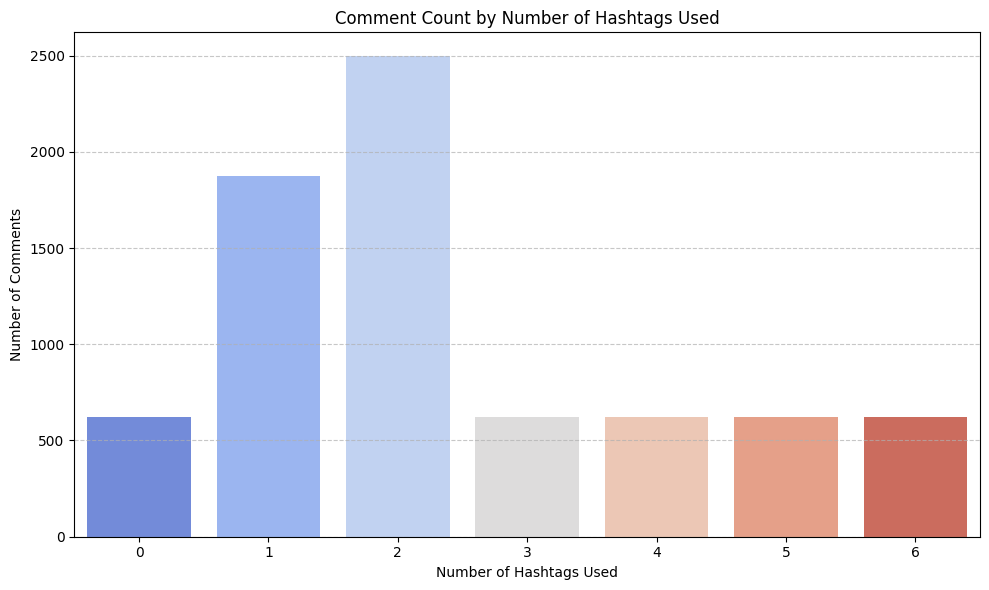

In [65]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Hashtags used count', y='comment_count', data=hashtag_perf, palette='coolwarm')
plt.title('Comment Count by Number of Hashtags Used')
plt.xlabel('Number of Hashtags Used')
plt.ylabel('Number of Comments')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

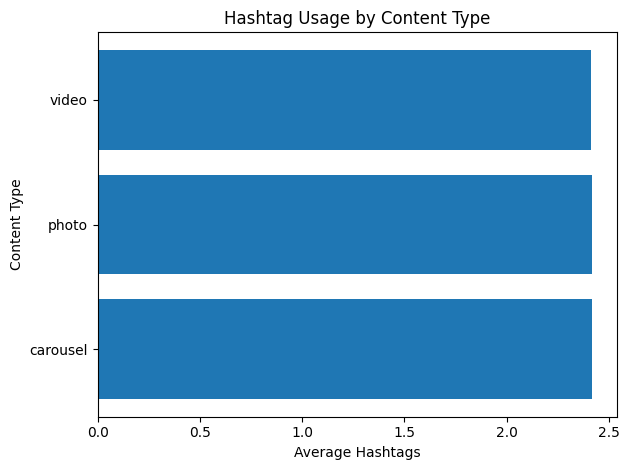

In [69]:
plt.figure()
plt.barh(content_performance['photo type'], content_performance['Hashtags used count'])

plt.title("Hashtag Usage by Content Type")
plt.xlabel("Average Hashtags")
plt.ylabel("Content Type")

plt.tight_layout()
plt.show()

In [ ]:
avg_comments_per_photo_type = merged_df.groupby('photo type')['Hashtags used count'].mean().reset_index()
avg_comments_per_photo_type = avg_comments_per_photo_type.rename(columns={'Hashtags used count': 'average_comment_count'})
display(avg_comments_per_photo_type)

,photo type,average_comment_count
0,carousel,2.417713
1,photo,2.416722
2,video,2.415516
